In [7]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np 
from pathlib import Path 
import seaborn as sns 
from scipy.stats import spearmanr

In [10]:
df_march = pd.read_csv("/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-03/test_predictions.csv")
df_june = pd.read_csv("/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-06/test_predictions.csv")
df_july = pd.read_csv("/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-07/test_predictions.csv")
df_agust = pd.read_csv("/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-08/test_predictions.csv")
df_sep = pd.read_csv("/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-09/test_predictions.csv")
df_oct = pd.read_csv("/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-10/test_predictions.csv")
df_nov = pd.read_csv("/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-11/test_predictions.csv")
df_dec = pd.read_csv("/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-12/test_predictions.csv")
df_jan = pd.read_csv("/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2026-01/test_predictions.csv")



In [3]:
base_dir = Path("/Users/YGT/ist-airport-decision-support-system/data/model/splits/monthly")

rows = []

for month_dir in sorted(base_dir.iterdir()):
    if not month_dir.is_dir():
        continue

    month = month_dir.name

    train_path = month_dir / "train.parquet"
    valid_path = month_dir / "valid.parquet"
    test_path  = month_dir / "test.parquet"

    train_df = pd.read_parquet(train_path, columns=["focusing_flight_id"])
    valid_df = pd.read_parquet(valid_path, columns=["focusing_flight_id"])
    test_df  = pd.read_parquet(test_path,  columns=["focusing_flight_id"])

    n_train = len(train_df)
    n_valid = len(valid_df)
    n_test  = len(test_df)

    n_total = n_train + n_valid + n_test

    n_flights = pd.concat([train_df, valid_df, test_df])["focusing_flight_id"].nunique()

    rows.append({
        "Month": month,
        "Flights": n_flights,
        "N_total_scenerio": n_total,
        "N_train": n_train,
        "N_valid": n_valid,
        "N_test": n_test,
    })

monthly_df = pd.DataFrame(rows).sort_values("Month")

monthly_df

,Month,Flights,N_total_scenerio,N_train,N_valid,N_test
0,2025-03,3016,15090,12070,1510,1510
1,2025-06,5025,25136,20119,2515,2502
2,2025-07,3790,18942,15153,1895,1894
3,2025-08,6019,30131,24091,3025,3015
4,2025-09,3509,17565,14055,1755,1755
5,2025-10,1173,5865,4690,585,590
6,2025-11,1387,6940,5550,695,695
7,2025-12,4040,20205,16165,2020,2020
8,2026-01,1952,9760,7805,975,980


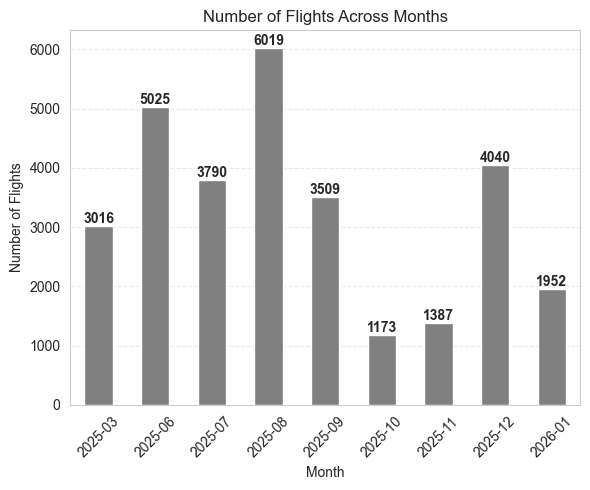

In [4]:
sns.set_style("whitegrid") 
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=monthly_df,
    x="Month",
    y="Flights",
    color="gray",
    width=0.5
)

plt.ylabel("Number of Flights")
plt.xlabel("Month")
plt.title("Number of Flights Across Months")

plt.xticks(rotation=45)

ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.xaxis.grid(False)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [5]:
monthly_df = monthly_df.sort_values("Month")

x = np.arange(len(monthly_df))

train = monthly_df["N_train"].values
valid = monthly_df["N_valid"].values
test  = monthly_df["N_test"].values

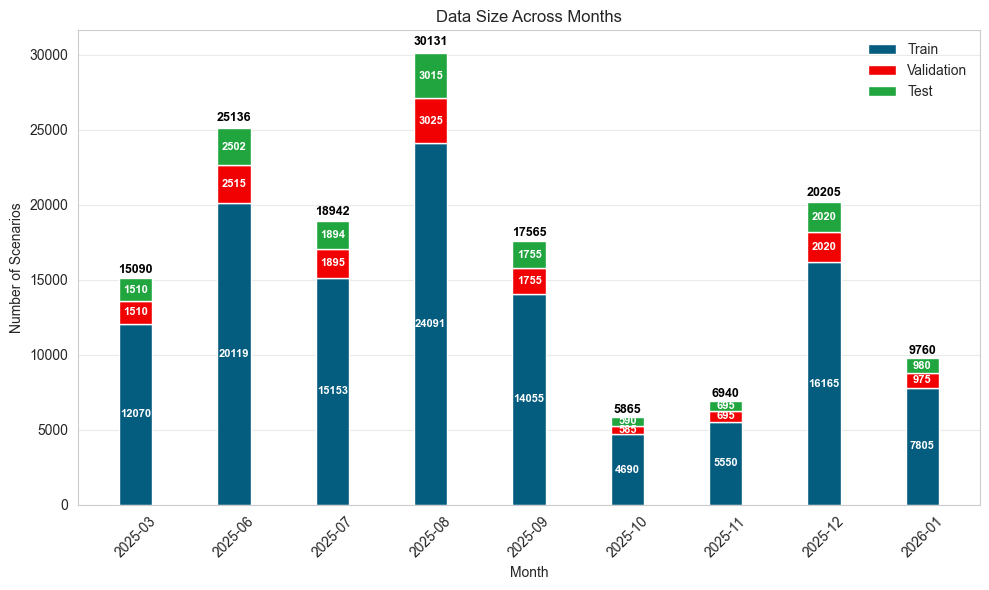

In [6]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")
plt.grid(axis='x', visible=False)
plt.grid(axis='y', linestyle='-', alpha=0.4)
width=0.34
bar1 = plt.bar(x, train, label="Train", color="#045C7F", width=width)
bar2 = plt.bar(x, valid, bottom=train, label="Validation", color="#F10101", width=width)
bar3 = plt.bar(x, test,  bottom=train+valid, label="Test", color="#20A53F",width=width)

def add_labels(bars, values, bottoms):
    for i, (bar, val, bottom) in enumerate(zip(bars, values, bottoms)):
        if val > 0:
            plt.text(
                bar.get_x() + bar.get_width()/2,
                bottom + val/2,
                f"{int(val)}",
                ha='center',
                va='center',
                fontsize=8,
                color="white",   
                fontweight='bold'
            )

add_labels(bar1, train, np.zeros_like(train))
add_labels(bar2, valid, train)
add_labels(bar3, test, train+valid)


totals = train + valid + test
for i, total in enumerate(totals):
    plt.text(
        x[i],
        total + total*0.01,
        f"{int(total)}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color="black"
    )


plt.xticks(x, monthly_df["Month"], rotation=45)
plt.ylabel("Number of Scenarios")
plt.xlabel("Month")
plt.title("Data Size Across Months")



plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [13]:
def regression_metrics(y_true, y_pred, n_features=1, file_path="file/path"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    path_obj = Path(file_path)
    month_name = path_obj.parent.name

    mae = round(mean_absolute_error(y_true, y_pred), 4)
    mse = round(mean_squared_error(y_true, y_pred), 4)
    rmse = round(np.sqrt(mse), 4)
    r2 = round(r2_score(y_true, y_pred), 4)

    n = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)


    epsilon = 1e-8
    smape = round(np.mean(
        np.abs(y_true - y_pred) / 
        (np.abs(y_true) + np.abs(y_pred) + epsilon)
    ) * 100, 4)


    return {
        "Month":[month_name],
        "MAE": [mae],
        "MSE": [mse],
        "RMSE": [rmse],
        "R2": [r2],
        "Adj_R2": [round(adj_r2,4)],
        "SMAPE": [round(smape,4)] 
 
    }

In [14]:
march_performance = regression_metrics(df_march["y_true"], df_march["y_pred"], file_path="/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-03/test_predictions.csv")
june_performance = regression_metrics(df_june["y_true"], df_june["y_pred"], file_path="/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-06/test_predictions.csv")
july_performance = regression_metrics(df_july["y_true"], df_july["y_pred"], file_path="/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-07/test_predictions.csv")
agust_performance = regression_metrics(df_agust["y_true"], df_agust["y_pred"], file_path="/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-08/test_predictions.csv")
september_performance = regression_metrics(df_sep["y_true"], df_sep["y_pred"], file_path="/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-09/test_predictions.csv")
oct_performance = regression_metrics(df_oct["y_true"], df_oct["y_pred"], file_path="/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-10/test_predictions.csv")
dec_performance = regression_metrics(df_dec["y_true"], df_dec["y_pred"], file_path="/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-12/test_predictions.csv")
november_performance = regression_metrics(df_nov["y_true"], df_nov["y_pred"], file_path="/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-11/test_predictions.csv")
january_performance = regression_metrics(df_jan["y_true"], df_jan["y_pred"], file_path="/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2026-01/test_predictions.csv")


In [18]:
df_perf = pd.concat([
    pd.DataFrame(march_performance),
    pd.DataFrame(june_performance),
    pd.DataFrame(july_performance),
    pd.DataFrame(agust_performance),
    pd.DataFrame(september_performance),
    pd.DataFrame(oct_performance),
    pd.DataFrame(november_performance),
    pd.DataFrame(dec_performance),
    pd.DataFrame(january_performance),
], ignore_index=True)

In [19]:
df_perf

,Month,MAE,MSE,RMSE,R2,Adj_R2,SMAPE
0,2025-03,2.0206,7.3706,2.7149,0.7934,0.7933,7.3084
1,2025-06,1.1614,4.4891,2.1187,0.9059,0.9059,5.6249
2,2025-07,1.2102,3.5811,1.8924,0.9140,0.9140,6.6411
3,2025-08,1.4517,5.0792,2.2537,0.8864,0.8864,5.5037
4,2025-09,2.3633,12.9002,3.5917,0.5643,0.5641,7.2053
5,2025-10,1.3894,4.1342,2.0333,0.9012,0.9010,6.3211
6,2025-11,2.0692,8.5511,2.9242,0.5474,0.5467,6.6058
7,2025-12,1.6320,7.4413,2.7279,0.7978,0.7977,5.5721
8,2026-01,2.2300,8.1053,2.8470,0.7071,0.7068,6.7398


In [11]:
# y_tru y_pred ikisinin dağılım grafiğini çizdir. histogram üst üste binmesi lazım.  poster makale yaz. 
# 11 12 haziran sunum tarihi 


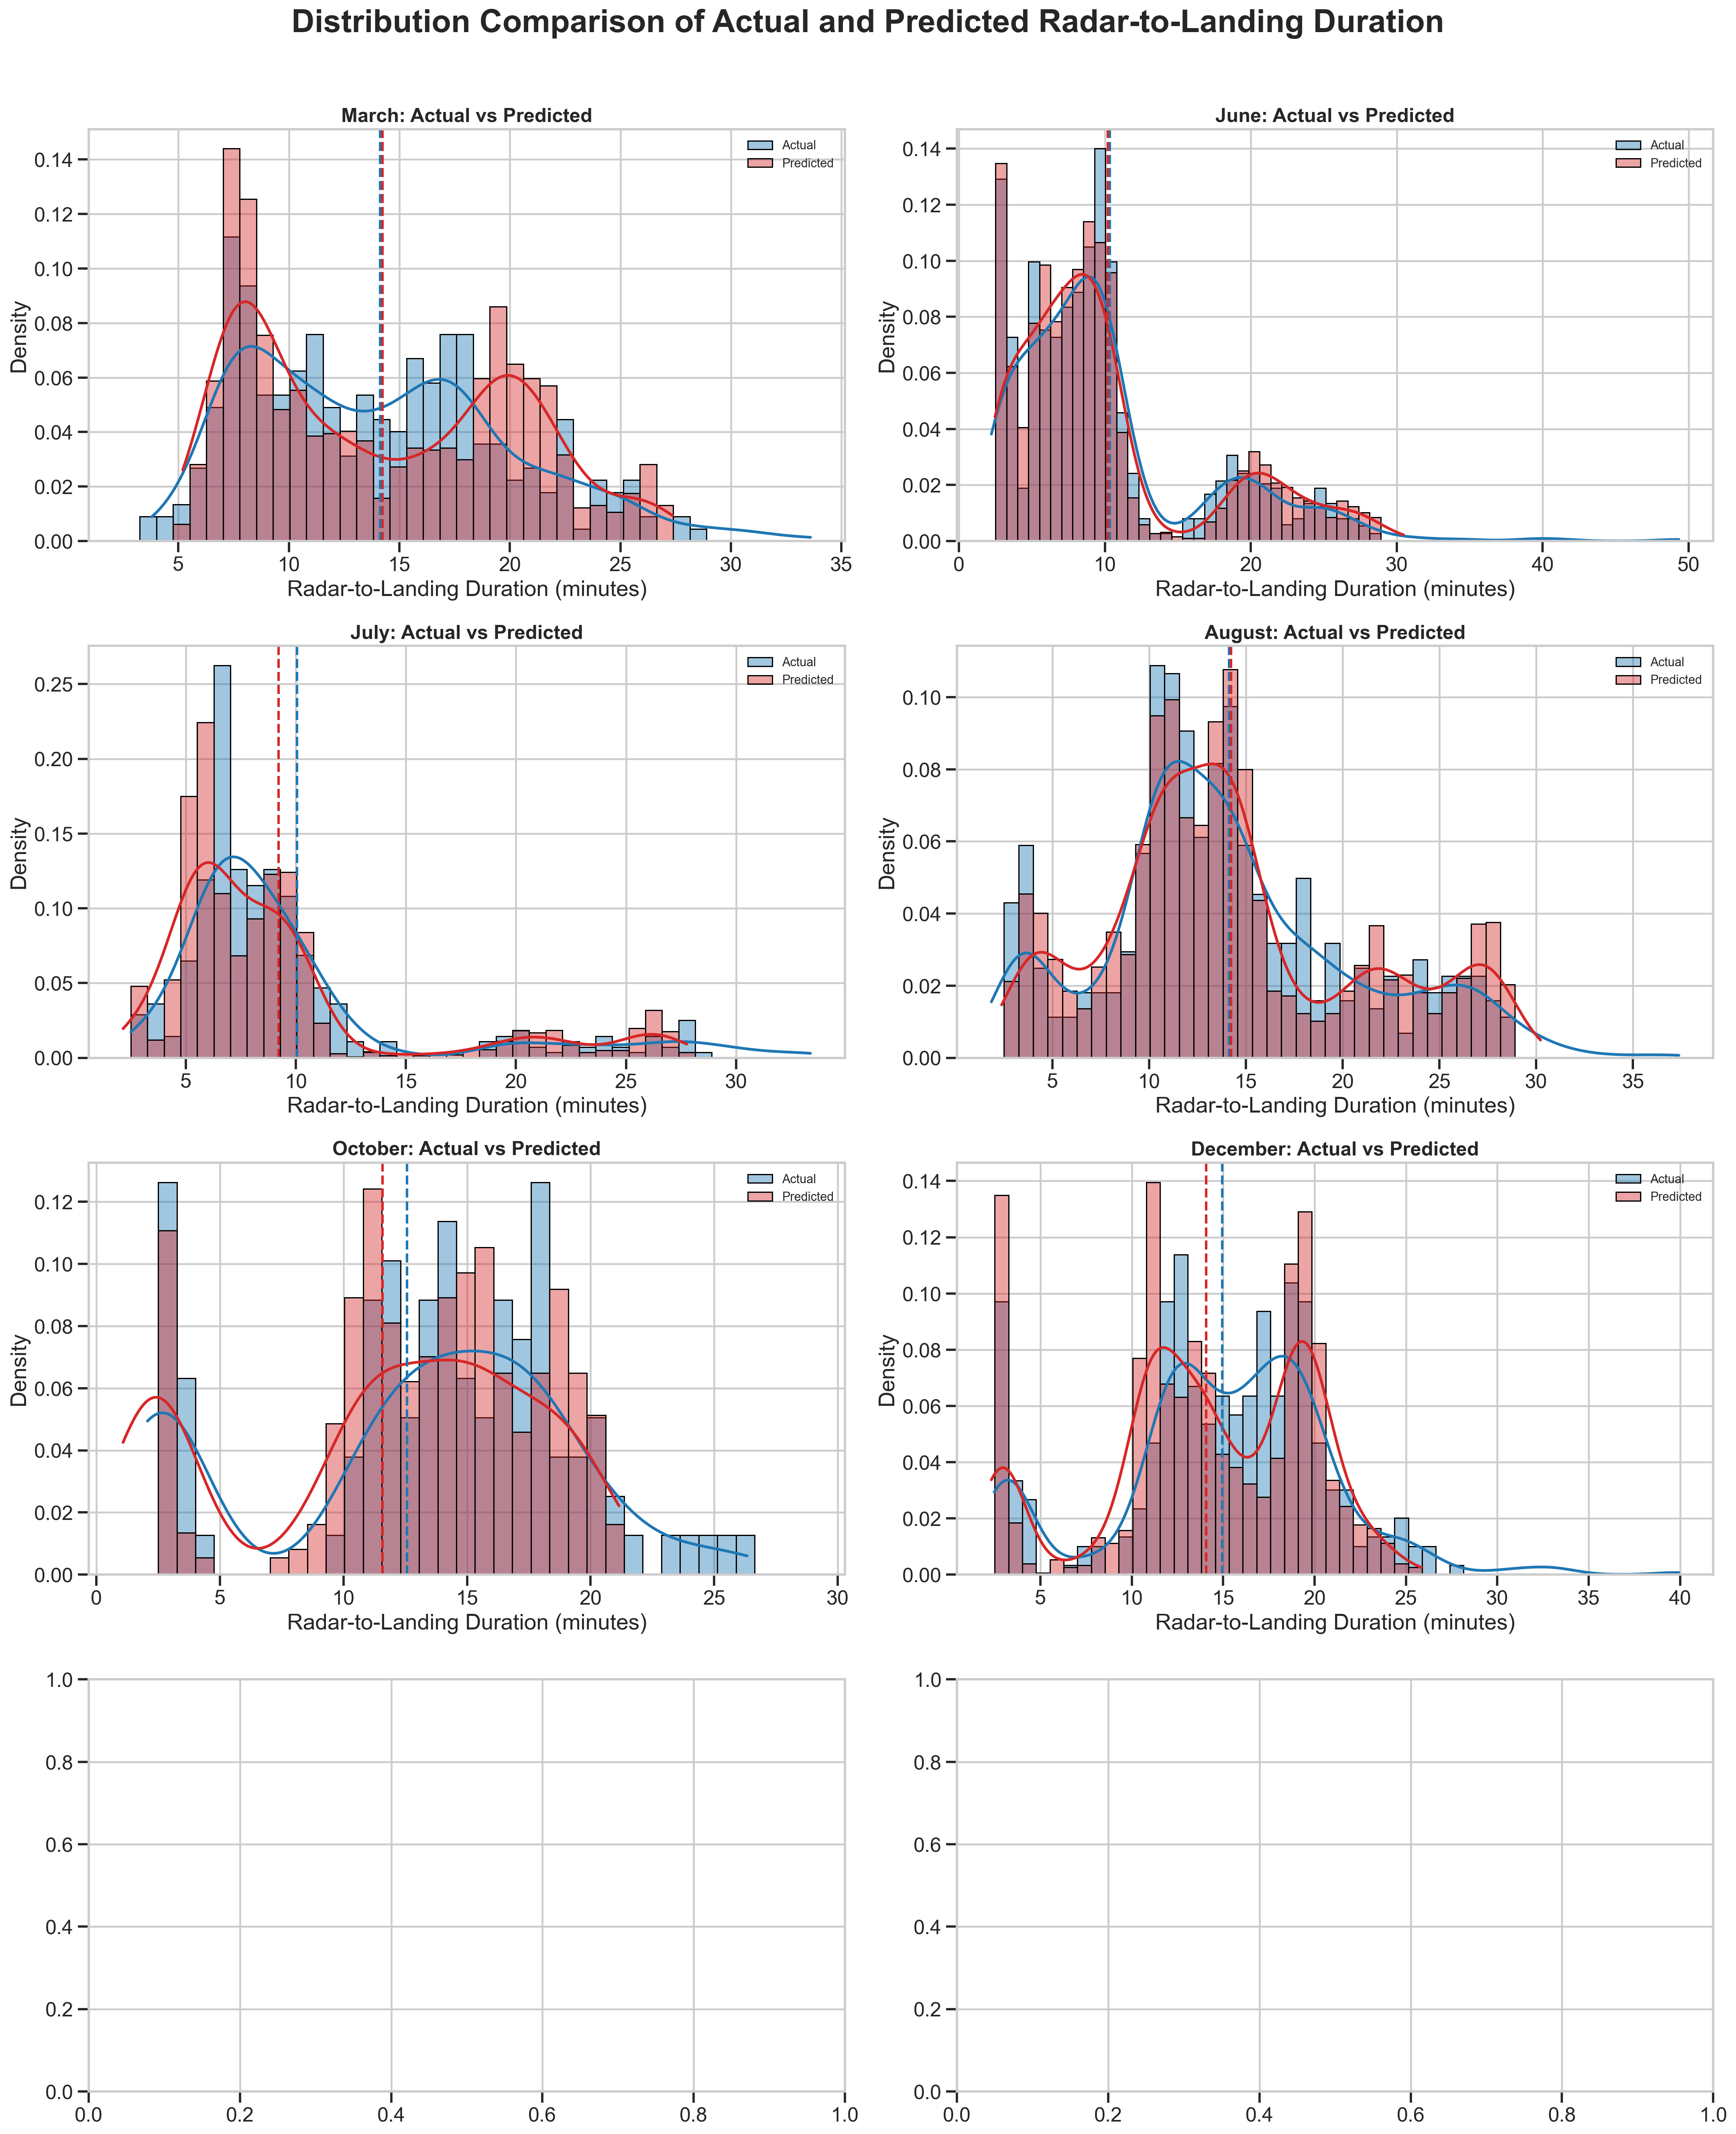

ValueError: Could not interpret value `month` for `x`. An entry with this name does not appear in `data`.

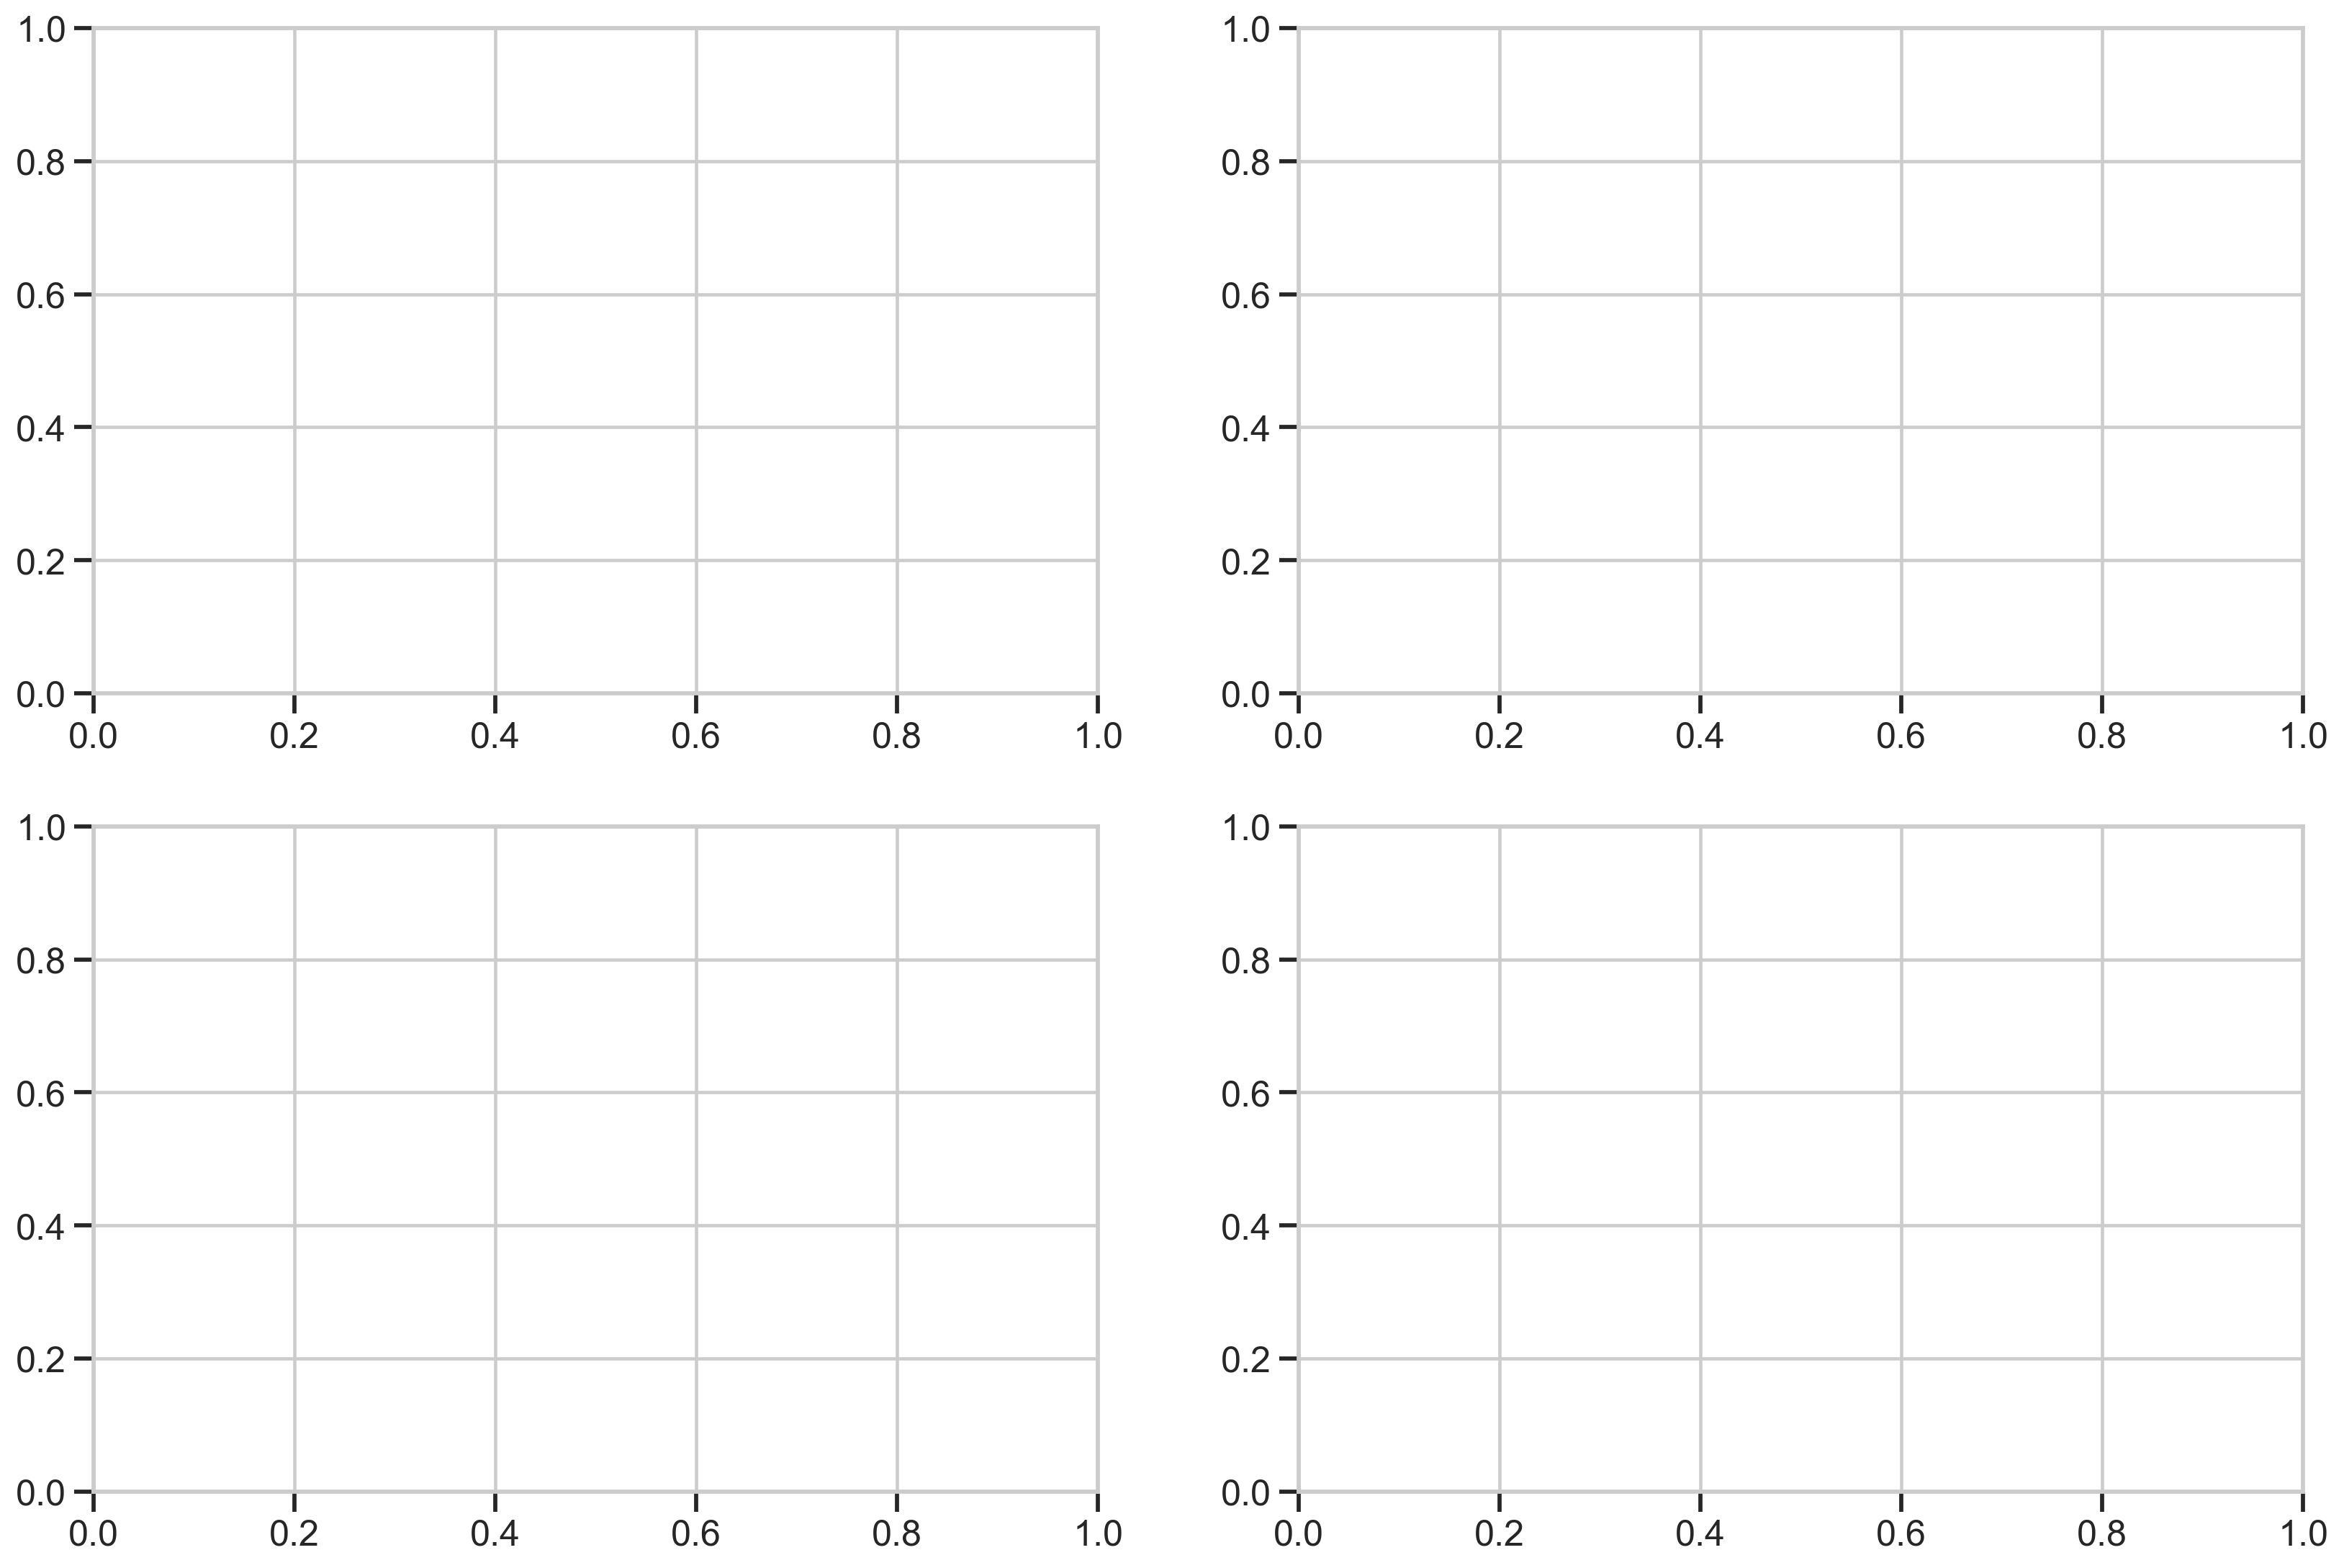

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ===================================================
# PERFORMANCE TABLE
# ===================================================
df_perf = pd.concat([
    pd.DataFrame(march_performance),
    pd.DataFrame(june_performance),
    pd.DataFrame(july_performance),
    pd.DataFrame(agust_performance),
    pd.DataFrame(oct_performance),
    pd.DataFrame(dec_performance),
    pd.DataFrame(january_performance)
], ignore_index=True)

# ---------------------------------------------------
# STYLE
# ---------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

# ===================================================
# MONTHLY DISTRIBUTION DATA
# ===================================================
monthly_data = {
    "March": df_march,
    "June": df_june,
    "July": df_july,
    "August": df_agust,
    "October": df_oct,
    "December": df_dec
}

# ---------------------------------------------------
# COLORS
# ---------------------------------------------------
true_color = "#1f77b4"
pred_color = "#d62728"

# ===================================================
# FIGURE
# ===================================================
fig, axes = plt.subplots(4, 2, figsize=(20, 24), dpi=220)
axes = axes.flatten()

# ---------------------------------------------------
# GLOBAL BINS
# ---------------------------------------------------
all_vals = []

for _, df in monthly_data.items():
    all_vals.extend(df["y_true"].values)
    all_vals.extend(df["y_pred"].values)

xmin = np.percentile(all_vals, 1)
xmax = np.percentile(all_vals, 99)

bins = np.linspace(xmin, xmax, 36)

# ===================================================
# PLOTS
# ===================================================
for i, (month, df) in enumerate(monthly_data.items()):

    ax = axes[i]

    # Actual
    sns.histplot(
        df["y_true"],
        bins=bins,
        stat="density",
        kde=True,
        color=true_color,
        alpha=0.42,
        linewidth=1,
        label="Actual",
        ax=ax
    )

    # Predicted
    sns.histplot(
        df["y_pred"],
        bins=bins,
        stat="density",
        kde=True,
        color=pred_color,
        alpha=0.42,
        linewidth=1,
        label="Predicted",
        ax=ax
    )

    # Mean lines
    ax.axvline(df["y_true"].mean(), linestyle="--", linewidth=2, color=true_color)
    ax.axvline(df["y_pred"].mean(), linestyle="--", linewidth=2, color=pred_color)

    # Title
    ax.set_title(
        f"{month}: Actual vs Predicted",
        fontsize=16,
        weight="bold"
    )

    ax.set_xlabel("Radar-to-Landing Duration (minutes)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=10)

# ===================================================
# MAIN TITLE
# ===================================================
fig.suptitle(
    "Distribution Comparison of Actual and Predicted Radar-to-Landing Duration",
    fontsize=26,
    weight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()


# ===================================================
# SECOND FIGURE : PERFORMANCE METRICS
# ===================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12), dpi=220)
axes = axes.flatten()

metrics = ["MAE", "RMSE", "R2", "MAPE"]

for i, metric in enumerate(metrics):

    ax = axes[i]

    sns.barplot(
        data=df_perf,
        x="month",
        y=metric,
        palette="viridis",
        ax=ax
    )

    ax.set_title(f"{metric} by Test Month", fontsize=16, weight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=35)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=9)

fig.suptitle(
    "Model Performance Across Evaluation Months",
    fontsize=24,
    weight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()